# Pooya Valizadeh
### CIFAR10 dataset project 2
www.github.com/pooyavalizadeh


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [46]:
(xtrain, ytrain), (xtest, ytest) = keras.datasets.cifar10.load_data()

In [47]:
x = np.concatenate([xtrain, xtest], axis=0)
y = np.concatenate([ytrain, ytest], axis=0)

In [48]:
from sklearn.model_selection import train_test_split as tts

xtrain , xtest , ytrain , ytest = tts(x,y,random_state=26,stratify=y,test_size=0.15)

In [49]:
xtrain , xval ,ytrain, yval = tts(xtrain,ytrain,random_state=26,test_size=0.2)

In [50]:
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((40800, 32, 32, 3), (40800, 1), (9000, 32, 32, 3), (9000, 1))

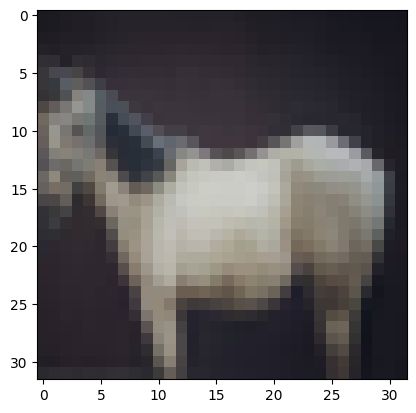

In [51]:
plt.imshow(xtrain[8585])

In [52]:
ytrain.shape

(40800, 1)

In [53]:
from keras.utils import to_categorical

ytrain = to_categorical(ytrain)
ytest = to_categorical(ytest)
yval = to_categorical(yval)

In [54]:
xtrain = xtrain / 255
xtest = xtest /255
xval = xval /255

# buildiing model

In [55]:
input_ = keras.layers.Input(shape = (32,32,3))
flat = keras.layers.Flatten()(input_)
dense = keras.layers.Dense(50,activation = "relu",kernel_initializer='zeros')(flat)
batch = keras.layers.BatchNormalization()(dense)
dense1 = keras.layers.Dense(50,activation = "relu",kernel_initializer='zeros')(batch)
batch1 = keras.layers.BatchNormalization()(dense1)
dense2 = keras.layers.Dense(10,activation = "softmax")(batch1)
model = keras.Model(input_,dense2)

In [56]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │       153,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,110 (613.71 KB)

 Trainable params: 156,910 (612.93 KB)

 Non-trainable params: 200 (800.00 B)

In [57]:
model.compile(optimizer= keras.optimizers.RMSprop(),loss = keras.losses.CategoricalCrossentropy() , metrics=[
    keras.metrics.CategoricalAccuracy()
    ])

In [58]:
history = model.fit(xtrain,ytrain,validation_data=(xval,yval),epochs=50)

Epoch 1/50
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - categorical_accuracy: 0.1000 - loss: 2.3031 - val_categorical_accuracy: 0.0946 - val_loss: 2.3033
Epoch 2/50
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - categorical_accuracy: 0.1015 - loss: 2.3031 - val_categorical_accuracy: 0.0997 - val_loss: 2.3037
Epoch 3/50
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - categorical_accuracy: 0.0992 - loss: 2.3031 - val_categorical_accuracy: 0.0990 - val_loss: 2.3029
Epoch 4/50
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - categorical_accuracy: 0.0985 - loss: 2.3031 - val_categorical_accuracy: 0.0997 - val_loss: 2.3030
Epoch 5/50
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - categorical_accuracy: 0.0986 - loss: 2.3029 - val_categorical_accuracy: 0.1025 - val_loss: 2.3033
Epoch 6/50
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - categorical_accuracy: 0.1004 - loss: 2.3029 - val_categorical_accuracy: 0.0946 - val_loss: 2.3037
Epoch 7/50
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - categorical_accuracy

<Axes: >

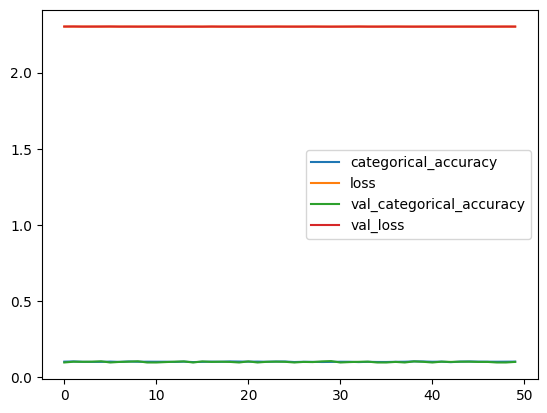

In [59]:
pd.DataFrame(history.history).plot()

In [67]:
model.get_weights()

[array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=fl

# **طبق نتایج بالا نتیجه می گیرم که مقدار دهی اولیه وزن ها به 0 باعث یاد نگرفتن مدل طی ایپاک ها می شود و دقت مدل 10 درصد تصادفی است پس در نتیجه فقط در لایه اخر مدل یاد می گیرد که تاثیر چندانی ندارد**


